Dataset has 2033 datapoints, and each datapoint has 10 results each.

In [12]:
import itertools

from numpy.f2py.auxfuncs import throw_error
from tqdm.notebook import tqdm
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def metadata_extractor(df_smaller):
    metadata = {"number_of_pairs":0,
                "pair_starting_indices":[],
                "pair_number_of_datapoints":[]}
    # preprocessed_df = df[df["predicted_score"]!= -1].copy()
    print("preprocessed_df.shape:", df_smaller.shape)
    current_prompt = ""
    number_of_points = 0
    for index, row in df_smaller.iterrows():
        if current_prompt != row["prompt"]:
            metadata["number_of_pairs"] += 1
            current_prompt = row["prompt"]
            metadata["pair_starting_indices"].append(index)
            metadata["pair_number_of_datapoints"].append(number_of_points)
            number_of_points = 1
        else:
            number_of_points += 1
    metadata["pair_number_of_datapoints"].append(number_of_points)
    metadata["pair_number_of_datapoints"] = metadata["pair_number_of_datapoints"][1:]
    return metadata

def data_reader(filename):
    """
    Reads the data from the json file into a pandas dataset
    :return:
    """
    df = pd.read_json(filename, lines=True)
    df.drop(df.index[~(df['predicted_score'] != -1)], inplace= True)
    df.reset_index(drop=True, inplace=True)
    # filtered_df = df[df["predicted_score"]!= -1]
    print("filtered_df.shape:", df.shape)
    return df, metadata_extractor(df)

class UCB:
    """
    Class that holds all the variables and runs the required algorithms.
    """
    def __init__(self, df, metadata):
        self.metadata = metadata
        self.dataframe = df
        self.n_pairs = metadata["number_of_pairs"] # total number of pairs
        self.llm_emperical_averages = [0.0] * self.n_pairs
        for pair in range(metadata["number_of_pairs"]):
            self.llm_emperical_averages[pair] = np.array(
                df.iloc[metadata["pair_starting_indices"][pair]:
                        metadata["pair_starting_indices"][pair]+metadata["pair_number_of_datapoints"][pair]]["predicted_score"]).mean()
        self.reset_algo()
        self.ucb_burn_in_factor = 2 * (1+(math.log(1/failure_probability_delta,2)*4)) # The algorithm only starts plotting stuff after self.n_pairs*self.ucb_burn_in_factor, the "2 *" is just to help ignore the bias from the initial points.

    def reset_algo(self):
        """
        Resets the required variables to start running the learning algorithm.
        """
        self.responses = [np.empty(0) for _ in range(self.n_pairs)]          # Number of times each arm was pulled
        self.ground_truth_variances = [0.0] * self.n_pairs
        self.ground_truth_variance_sum = 0
        for pair in range(self.n_pairs): # precompute all the ground truth variances.
            self.ground_truth_variances[pair] = self.get_ground_truth_variance(pair)
            self.ground_truth_variance_sum += self.ground_truth_variances[pair]

    def select_pair(self, selection_method = "ucb"):
        """
        Chooses the next pair to start questioning based on the chosen method.
        Uses a weighted method of choosing the best response for ucb and ground_variance. Also has a max_ucb that just chooses the pair with the highest variance upper bound.
        :param selection_method: "ucb", "ground_variance"
        """
        # If any pair hasn't been tried 4log(1/\delta), try it first
        for pair in range(self.n_pairs):
            if self.responses[pair].shape[0] < 2:
                return pair

        if selection_method == "max_ucb":
            selection_criteria_values = [0.0] * self.n_pairs
            for pair in range(self.n_pairs):
                if self.responses[pair].shape[0] < math.log(1/failure_probability_delta,2)*4: # Minimum N from the condition.
                    return pair
            for pair in range(self.n_pairs):
                selection_criteria_values[pair] = self.get_ucb_value(pair)#/Number of arm pulls.
            return selection_criteria_values.index(max(selection_criteria_values))


        if selection_method == "ucb":
            selection_criteria_values = [0.0] * self.n_pairs
            selection_criteria_sum = 0
            for pair in range(self.n_pairs):
                selection_criteria_values[pair] = self.get_ucb_value(pair)
                selection_criteria_sum += selection_criteria_values[pair]
            return np.random.choice(len(selection_criteria_values), p=selection_criteria_values / selection_criteria_sum)

        if selection_method == "ucb_without_bonus": # This is basically sampling proportional to the sample variance.
            selection_criteria_values = [0.0] * self.n_pairs
            selection_criteria_sum = 0
            for pair in range(self.n_pairs):
                selection_criteria_values[pair] = self.get_sample_covariance(self.responses[pair])# self.get_ucb_value(pair)
                selection_criteria_sum += selection_criteria_values[pair]
            return np.random.choice(len(selection_criteria_values), p=selection_criteria_values / selection_criteria_sum)


        if selection_method == "ground_variance":
            return np.random.choice(len(self.ground_truth_variances), p=self.ground_truth_variances / self.ground_truth_variance_sum)


    def get_pair_information(self, pair, information):
        """
        Helper function to get any required information about a pair.
        It also gives the next_predicted score to fake data being present.
        :param pair:
        :param information:
        :return:
        """
        if information == "next_predicted_score":
            try:
                return self.dataframe.iloc[self.metadata["pair_starting_indices"][pair]
                    +np.random.randint(self.metadata["pair_number_of_datapoints"][pair])]["predicted_score"]
            except:
                print("error pair:", pair)
                raise
        elif information == "llm_average_score":
            return self.llm_emperical_averages[pair]

    def get_ground_truth_variance(self, pair):
        """
        Gets the ground truth variance of the judge LLM of the pair by taking \Sum_{i=1}^{10}{(sample_i - mean_score)^2}/10
        :param pair:
        :return: the ground truth variance of the pair in question.
        """
        ground_truth_var = np.square(np.array(self.dataframe.iloc[self.metadata["pair_starting_indices"][pair]:self.metadata["pair_starting_indices"][pair]+self.metadata["pair_number_of_datapoints"][pair]]["predicted_score"]) - np.array(self.dataframe.iloc[self.metadata["pair_starting_indices"][pair]:self.metadata["pair_starting_indices"][pair]+self.metadata["pair_number_of_datapoints"][pair]]["predicted_score"]).mean()).sum()/self.metadata["pair_number_of_datapoints"][pair]
        return ground_truth_var

    def get_ucb_value(self, pair_number):
        """
        Gets the ground truth variance of the judge LLM of the pair by taking \Sum_{i=1}^{10}{(sample_i - mean_score)^2}/10
        :param pair_number:
        :return:
        """
        return self.get_sample_covariance(self.responses[pair_number])/(1-(2*math.sqrt(math.log(1/failure_probability_delta,2)/(self.responses[pair_number].shape[0]))))

    def get_sample_covariance(self, selected_pair_responses):
        """
        Gets the sample variance of the judge LLM of the pair by taking \Sum_{i=1}^{n(t)}{(sample_i - emperical_sample_mean)^2}/(n(t) - 1)
        :param pair:
        :return: the sample variance of the pair in question.
        """
        return np.square(selected_pair_responses-selected_pair_responses.mean()).sum()/(selected_pair_responses.shape[0]-1)

    def get_all_sample_covariance(self):
        """
        Calculates sample variances of each datapoint pair.
        :return: all the sample variances of the datapoint pairs as an array.
        """
        to_return = []
        for pair in range(self.n_pairs):
            to_return.append(self.get_sample_covariance(self.responses[pair]))
        to_return = np.array(to_return)
        return to_return

    def update(self, chosen_pair):
        """
        Pseudo-queries a new pair's value in total and updates it to the list of responses that the pair got so far.
        Updates the responses list is place.
        :param chosen_pair: pair to be updated.
        """
        new_value = self.get_pair_information(chosen_pair, information="next_predicted_score")
        clipped_new_value = max(min(new_value, 5), 0)
        self.responses[chosen_pair] = np.append(self.responses[chosen_pair], clipped_new_value)

    def get_total_error(self, type = "standard_error"): # change human score to emperical mean.
        total_error = 0
        if type == "standard_error":
            for pair in range(self.n_pairs):
                total_error += (self.get_pair_information(pair, "llm_average_score") - self.responses[pair].mean())**2
        return total_error

    def get_total_sample_variance_normalized(self):
        total_vars = 0
        for pair in range(self.n_pairs):
            total_vars += (self.get_sample_covariance(self.responses[pair])/len(self.responses[pair]))
        return total_vars

    def get_ground_truth_variance_divided_by_samples(self):
        total_vars = 0
        for pair in range(self.n_pairs):
            total_vars += (self.ground_truth_variances[pair]/len(self.responses[pair]))
        return total_vars

    def run_algo_uniform(self, number_of_queries, error_type = "standard_error"):
        self.reset_algo()
        total_errors = []
        average_sample_variance_by_number_of_samples = []
        average_true_variance_by_number_of_samples = []
        for iteration in tqdm(range(int(number_of_queries))):
            pair_number = iteration%self.n_pairs
            algorithm.update(pair_number)
            if  iteration > self.n_pairs*self.ucb_burn_in_factor and iteration % 100 == 0:
                total_errors.append(self.get_total_error(error_type))
                average_sample_variance_by_number_of_samples.append(self.get_total_sample_variance_normalized())
                average_true_variance_by_number_of_samples.append(self.get_ground_truth_variance_divided_by_samples())
        return total_errors, average_sample_variance_by_number_of_samples, average_true_variance_by_number_of_samples


    def run_algo_UCB(self, number_of_queries, error_type = "standard_error"):
        self.reset_algo()
        total_errors = []
        average_sample_variance_by_number_of_samples = []
        average_true_variance_by_number_of_samples = []
        for iteration in tqdm(range(int(number_of_queries))):
            if iteration <= self.n_pairs*self.ucb_burn_in_factor: #allowing for round robin before burn in period. The +1 is needed because we want to accound for the threshold being 4.1, and iteration being at 4.1*number of pairs, but the rest of the dataset has only had 4 evaluations.
                most_uncertain_pair = iteration%self.n_pairs
            else:
                most_uncertain_pair = algorithm.select_pair(selection_method = "ucb")
            if most_uncertain_pair is None:
                raise
            if iteration > self.n_pairs*self.ucb_burn_in_factor and iteration % 100 == 0:
                total_errors.append(self.get_total_error(error_type))
                average_sample_variance_by_number_of_samples.append(self.get_total_sample_variance_normalized())
                average_true_variance_by_number_of_samples.append(self.get_ground_truth_variance_divided_by_samples())
            algorithm.update(most_uncertain_pair)
        return total_errors, average_sample_variance_by_number_of_samples, average_true_variance_by_number_of_samples

    def run_algo_sample_variance(self, number_of_queries, error_type = "standard_error"):
        self.reset_algo()
        total_errors = []
        average_sample_variance_by_number_of_samples = []
        average_true_variance_by_number_of_samples = []
        for iteration in tqdm(range(int(number_of_queries))):
            if iteration <= self.n_pairs*self.ucb_burn_in_factor: #allowing for round robin before burn in period. The +1 is needed because we want to accound for the threshold being 4.1, and iteration being at 4.1*number of pairs, but the rest of the dataset has only had 4 evaluations.
                most_uncertain_pair = iteration%self.n_pairs
            else:
                most_uncertain_pair = algorithm.select_pair(selection_method = "ucb_without_bonus")
            if most_uncertain_pair is None:
                raise
            if iteration > self.n_pairs*self.ucb_burn_in_factor and iteration % 100 == 0:
                total_errors.append(self.get_total_error(error_type))
                average_sample_variance_by_number_of_samples.append(self.get_total_sample_variance_normalized())
                average_true_variance_by_number_of_samples.append(self.get_ground_truth_variance_divided_by_samples())
            algorithm.update(most_uncertain_pair)
        return total_errors, average_sample_variance_by_number_of_samples, average_true_variance_by_number_of_samples

    def run_algo_ground_truth_var(self, number_of_queries, error_type = "standard_error"):
        self.reset_algo()
        total_errors = []
        average_sample_variance_by_number_of_samples = []
        average_true_variance_by_number_of_samples = []
        for iteration in tqdm(range(int(number_of_queries))):
            chosen_pair = algorithm.select_pair(selection_method = "ground_variance")
            if iteration > self.n_pairs*self.ucb_burn_in_factor and iteration % 100 == 0:
                total_errors.append(self.get_total_error(error_type))
                average_sample_variance_by_number_of_samples.append(self.get_total_sample_variance_normalized())
                average_true_variance_by_number_of_samples.append(self.get_ground_truth_variance_divided_by_samples())
            algorithm.update(chosen_pair)
        return total_errors, average_sample_variance_by_number_of_samples, average_true_variance_by_number_of_samples

# Running Multiple Files

In [13]:
def plot_graphs(list_of_group_of_graphs,list_of_groups_of_metadata, delta):
    """
    :param list_of_group_of_graphs: [[data_1, data_2, ...], [data_1, data_2, ...]]
    :param list_of_groups_of_data: [{"title": "actual_title", "x_axis": "label_for_x_axis", "y_axis": "label_for_y_axis", "data_labels": ["UCB Errors", "Uniform Errors", "Ground Truth Variance Errors"]}, {...}]
    :param delta: "Delta from the algorithm"
    :return: Will plot the graphs.
    """
    for index, graph in enumerate(list_of_groups_of_metadata):
        plt.figure(figsize=(12, 8))
        for data_index in range(len(list_of_group_of_graphs[index])):
            plt.plot(list_of_group_of_graphs[index][data_index], label=list_of_groups_of_metadata[index]["data_labels"][data_index])
        plt.title(list_of_groups_of_metadata[index]["title"]+"delta="+str(delta))
        plt.xlabel(list_of_groups_of_metadata[index]["x_axis"])
        plt.ylabel(list_of_groups_of_metadata[index]["y_axis"])
        plt.legend()
        plt.grid(True)
        plt.show()

In [14]:
files = ["data/helpsteer2.jsonl","data/helpsteer2_complexity.jsonl","data/helpsteer2_correctness.jsonl","data/helpsteer2_helpfulness.jsonl","data/helpsteer2_verbosity.jsonl"]
number_of_queries_per_pair = 30
failure_probability_delta = 0.49 # When delta is 0.5, and N hits 4 the UCB value has a divide by zero error.
# First file is the old data (not many samples)


filtered_df.shape: (28264, 5)
preprocessed_df.shape: (28264, 5)
Skipping first 10407.134668285826 iterations.


  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

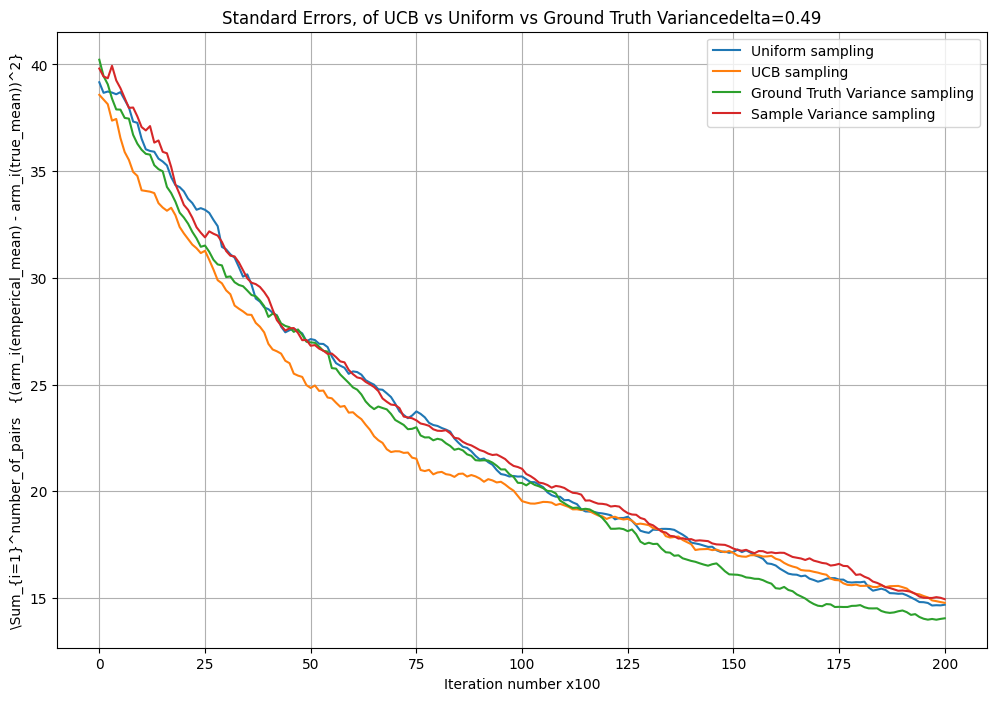

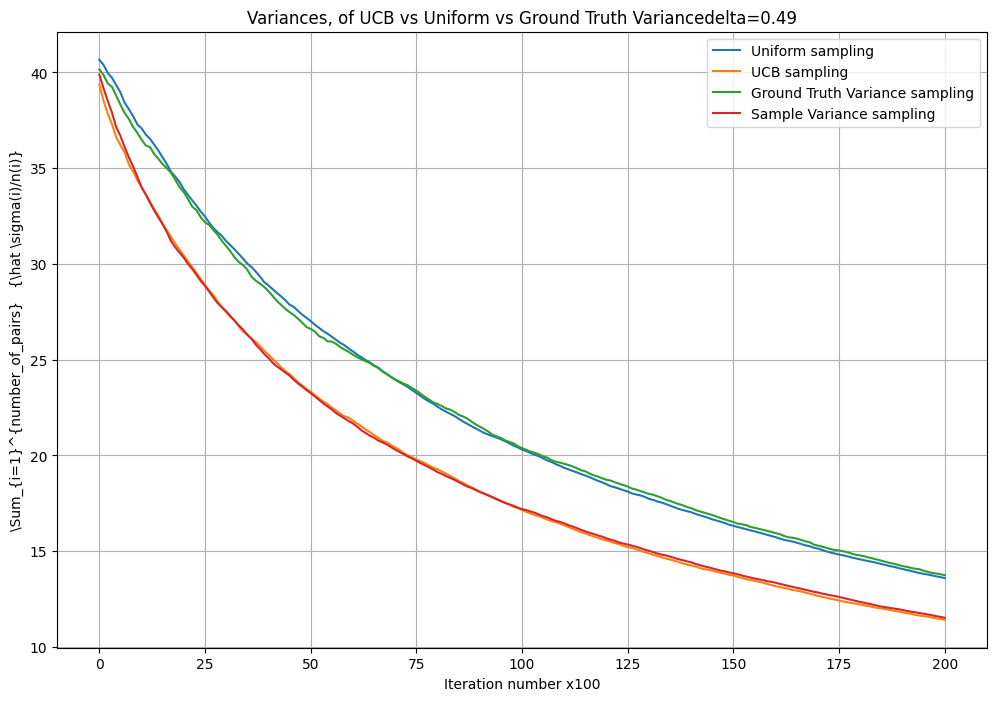

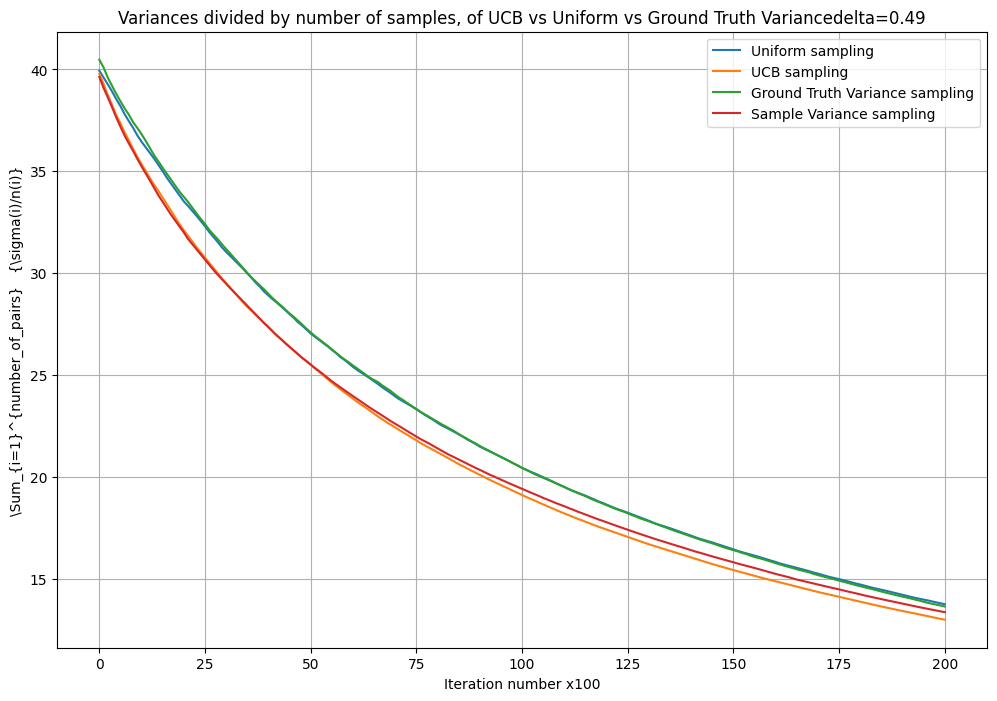

In [19]:
df, metadata = data_reader(files[1])
algorithm = UCB(df, metadata)
number_of_queries = metadata["number_of_pairs"]*number_of_queries_per_pair
print(f"Skipping first {algorithm.n_pairs*algorithm.ucb_burn_in_factor} iterations.")

uniform_errors, uniform_variances, uniform_divided_ground_variance = algorithm.run_algo_uniform(number_of_queries=number_of_queries)
UCB_errors, UCB_variances, UCB_divided_ground_variance = algorithm.run_algo_UCB(number_of_queries=number_of_queries)
ground_truth_variance_errors, ground_truth_variance_variances, ground_truth_variance_divided_ground_variance = algorithm.run_algo_ground_truth_var(number_of_queries=number_of_queries)
sample_variance_errors, sample_variance_variances, sample_variance_divided_ground_variance = algorithm.run_algo_sample_variance(number_of_queries=number_of_queries)

list_of_data_groups = []
metadata_graphs = []

list_of_data_groups.append([uniform_errors, UCB_errors, ground_truth_variance_errors,sample_variance_errors])
metadata_graphs.append({"title": "Standard Errors, of UCB vs Uniform vs Ground Truth Variance", "x_axis": 'Iteration number x100', "y_axis": '\Sum_{i=1}^number_of_pairs   {(arm_i(emperical_mean) - arm_i(true_mean))^2}', "data_labels": ["Uniform sampling", "UCB sampling", "Ground Truth Variance sampling","Sample Variance sampling"]})

list_of_data_groups.append([uniform_variances, UCB_variances, ground_truth_variance_variances, sample_variance_variances])
metadata_graphs.append({"title": "Variances, of UCB vs Uniform vs Ground Truth Variance", "x_axis": 'Iteration number x100', "y_axis": '\Sum_{i=1}^{number_of_pairs}   {\hat \sigma(i)/n(i)}', "data_labels": ["Uniform sampling", "UCB sampling", "Ground Truth Variance sampling", "Sample Variance sampling"]})

list_of_data_groups.append([uniform_divided_ground_variance, UCB_divided_ground_variance, ground_truth_variance_divided_ground_variance, sample_variance_divided_ground_variance])
metadata_graphs.append({"title": "Variances divided by number of samples, of UCB vs Uniform vs Ground Truth Variance", "x_axis": 'Iteration number x100', "y_axis": '\Sum_{i=1}^{number_of_pairs}   {\sigma(i)/n(i)}', "data_labels": ["Uniform sampling", "UCB sampling", "Ground Truth Variance sampling", "Sample Variance sampling"]})

plot_graphs(list_of_group_of_graphs=list_of_data_groups,list_of_groups_of_metadata=metadata_graphs, delta=failure_probability_delta)

filtered_df.shape: (29011, 5)
preprocessed_df.shape: (29011, 5)
Skipping first 10407.134668285826 iterations.


  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

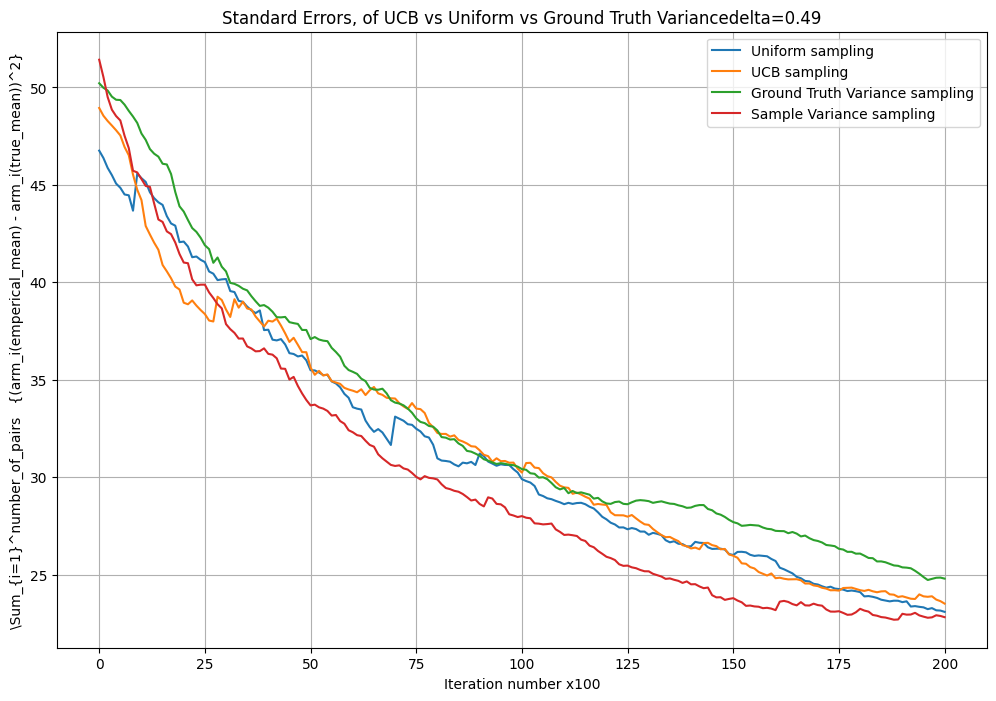

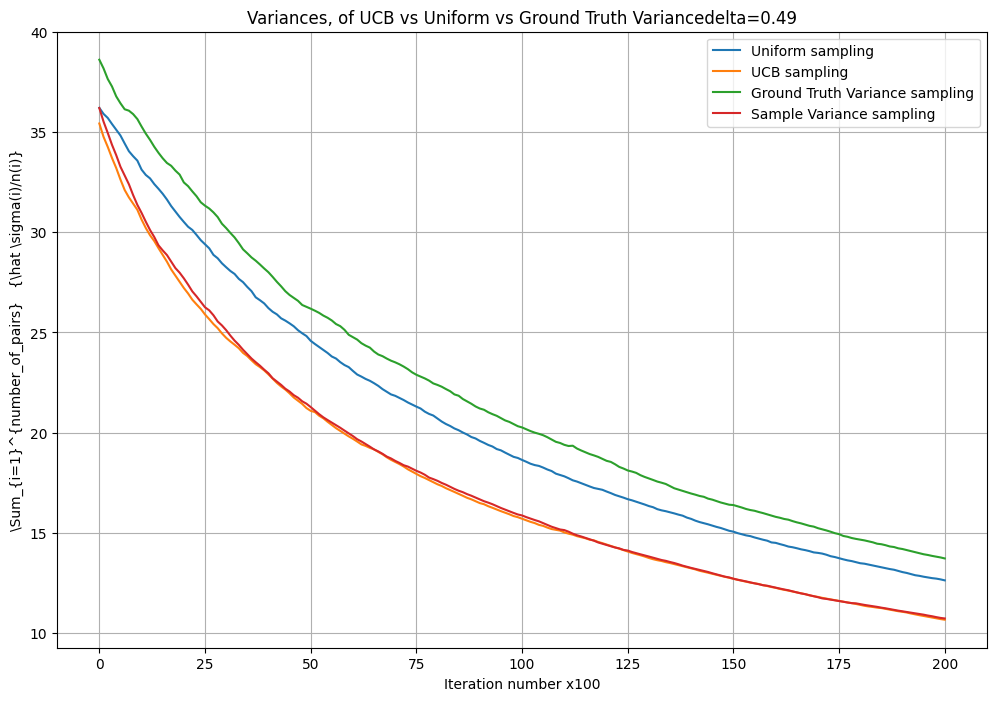

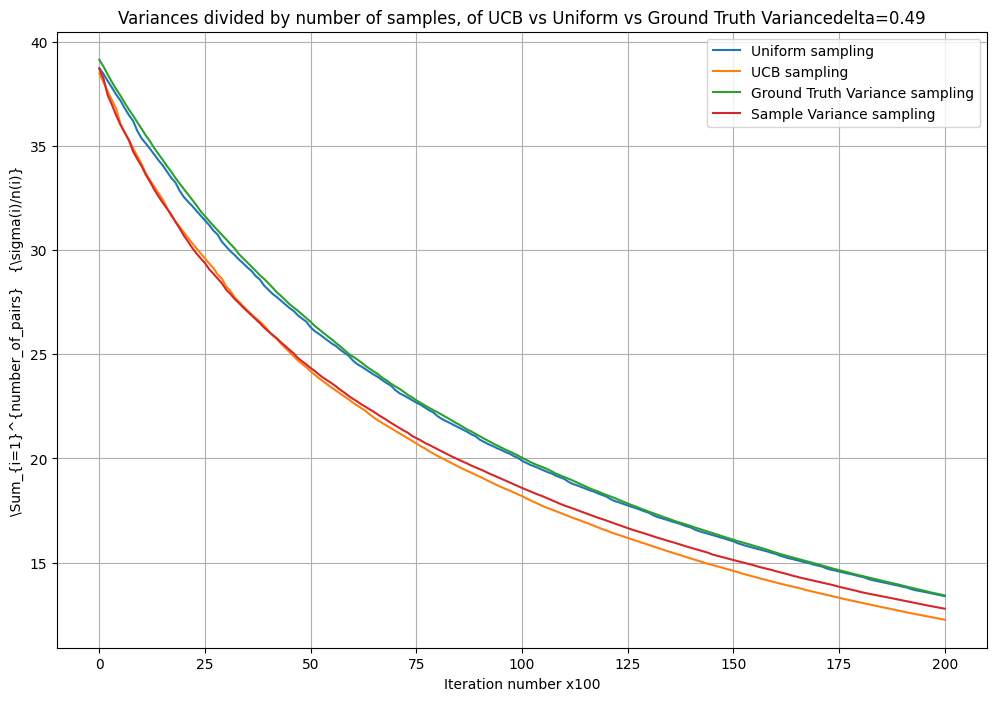

In [16]:
df, metadata = data_reader(files[2])
algorithm = UCB(df, metadata)
number_of_queries = metadata["number_of_pairs"]*number_of_queries_per_pair
print(f"Skipping first {algorithm.n_pairs*algorithm.ucb_burn_in_factor} iterations.")

uniform_errors, uniform_variances, uniform_divided_ground_variance = algorithm.run_algo_uniform(number_of_queries=number_of_queries)
UCB_errors, UCB_variances, UCB_divided_ground_variance = algorithm.run_algo_UCB(number_of_queries=number_of_queries)
ground_truth_variance_errors, ground_truth_variance_variances, ground_truth_variance_divided_ground_variance = algorithm.run_algo_ground_truth_var(number_of_queries=number_of_queries)
sample_variance_errors, sample_variance_variances, sample_variance_divided_ground_variance = algorithm.run_algo_sample_variance(number_of_queries=number_of_queries)

list_of_data_groups = []
metadata_graphs = []

list_of_data_groups.append([uniform_errors, UCB_errors, ground_truth_variance_errors,sample_variance_errors])
metadata_graphs.append({"title": "Standard Errors, of UCB vs Uniform vs Ground Truth Variance", "x_axis": 'Iteration number x100', "y_axis": '\Sum_{i=1}^number_of_pairs   {(arm_i(emperical_mean) - arm_i(true_mean))^2}', "data_labels": ["Uniform sampling", "UCB sampling", "Ground Truth Variance sampling","Sample Variance sampling"]})

list_of_data_groups.append([uniform_variances, UCB_variances, ground_truth_variance_variances, sample_variance_variances])
metadata_graphs.append({"title": "Variances, of UCB vs Uniform vs Ground Truth Variance", "x_axis": 'Iteration number x100', "y_axis": '\Sum_{i=1}^{number_of_pairs}   {\hat \sigma(i)/n(i)}', "data_labels": ["Uniform sampling", "UCB sampling", "Ground Truth Variance sampling", "Sample Variance sampling"]})

list_of_data_groups.append([uniform_divided_ground_variance, UCB_divided_ground_variance, ground_truth_variance_divided_ground_variance, sample_variance_divided_ground_variance])
metadata_graphs.append({"title": "Variances divided by number of samples, of UCB vs Uniform vs Ground Truth Variance", "x_axis": 'Iteration number x100', "y_axis": '\Sum_{i=1}^{number_of_pairs}   {\sigma(i)/n(i)}', "data_labels": ["Uniform sampling", "UCB sampling", "Ground Truth Variance sampling", "Sample Variance sampling"]})

plot_graphs(list_of_group_of_graphs=list_of_data_groups,list_of_groups_of_metadata=metadata_graphs, delta=failure_probability_delta)

filtered_df.shape: (29729, 5)
preprocessed_df.shape: (29729, 5)
Skipping first 10407.134668285826 iterations.


  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

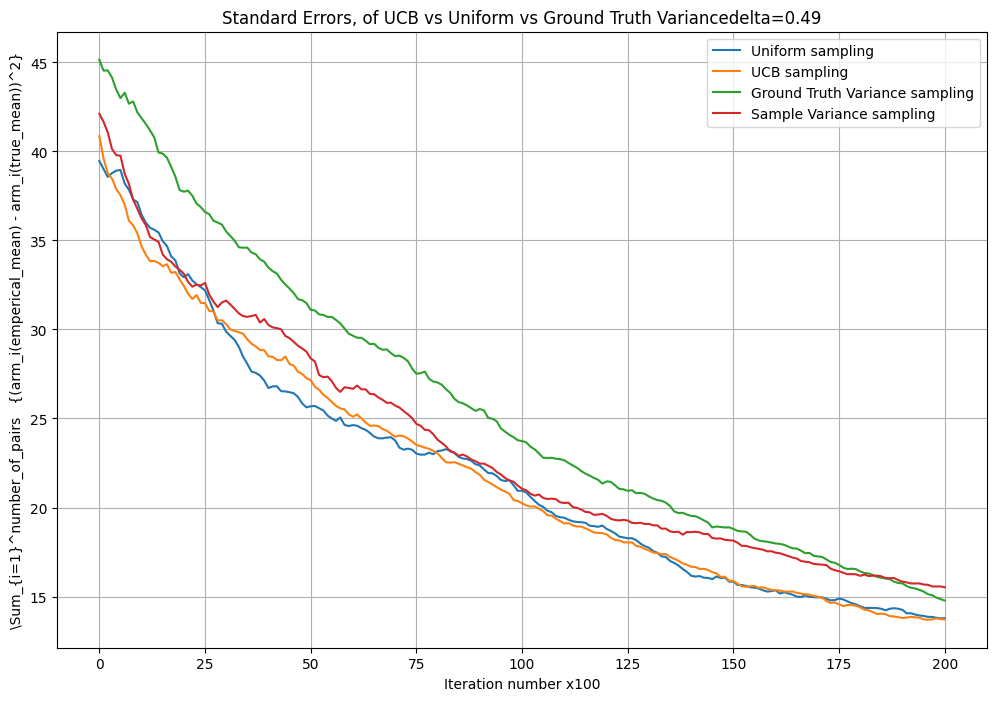

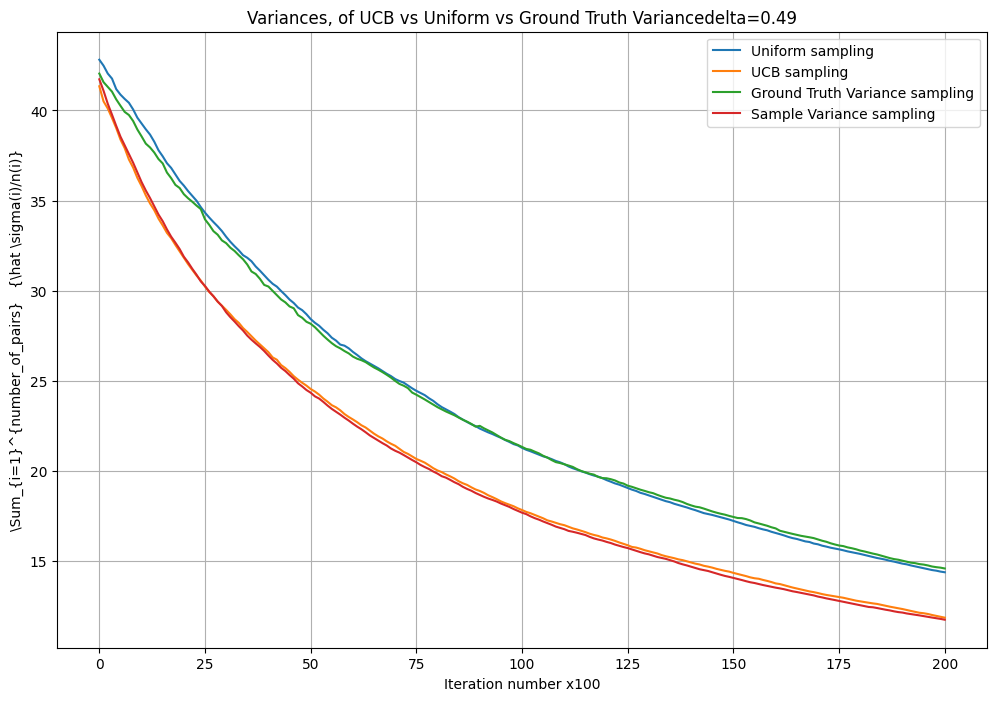

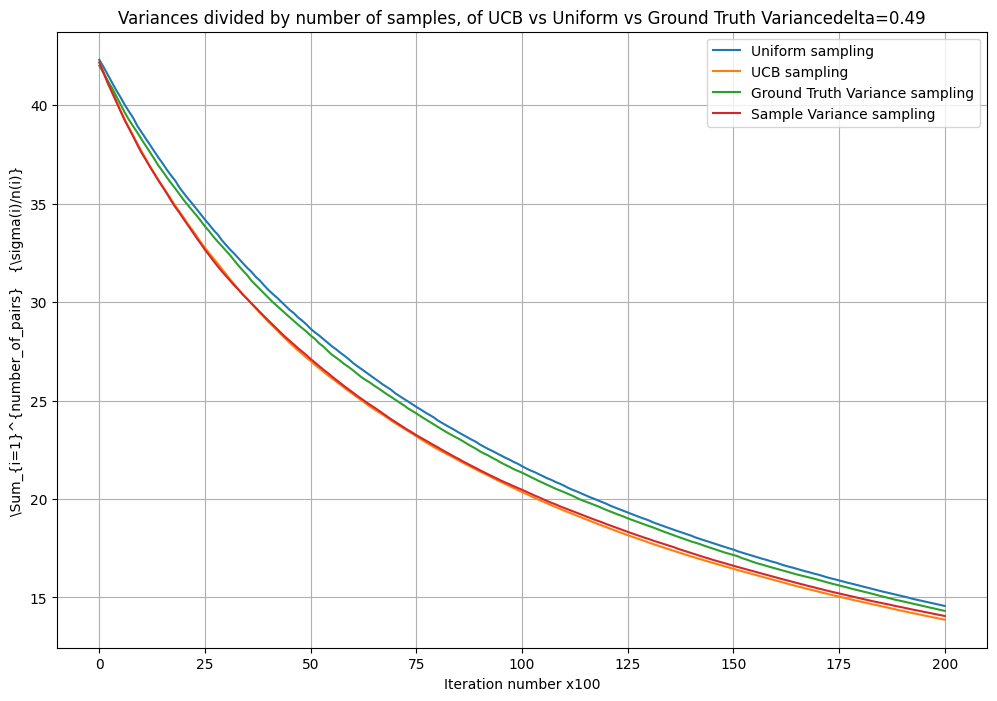

In [17]:
df, metadata = data_reader(files[3])
algorithm = UCB(df, metadata)
number_of_queries = metadata["number_of_pairs"]*number_of_queries_per_pair
print(f"Skipping first {algorithm.n_pairs*algorithm.ucb_burn_in_factor} iterations.")

uniform_errors, uniform_variances, uniform_divided_ground_variance = algorithm.run_algo_uniform(number_of_queries=number_of_queries)
UCB_errors, UCB_variances, UCB_divided_ground_variance = algorithm.run_algo_UCB(number_of_queries=number_of_queries)
ground_truth_variance_errors, ground_truth_variance_variances, ground_truth_variance_divided_ground_variance = algorithm.run_algo_ground_truth_var(number_of_queries=number_of_queries)
sample_variance_errors, sample_variance_variances, sample_variance_divided_ground_variance = algorithm.run_algo_sample_variance(number_of_queries=number_of_queries)

list_of_data_groups = []
metadata_graphs = []

list_of_data_groups.append([uniform_errors, UCB_errors, ground_truth_variance_errors,sample_variance_errors])
metadata_graphs.append({"title": "Standard Errors, of UCB vs Uniform vs Ground Truth Variance", "x_axis": 'Iteration number x100', "y_axis": '\Sum_{i=1}^number_of_pairs   {(arm_i(emperical_mean) - arm_i(true_mean))^2}', "data_labels": ["Uniform sampling", "UCB sampling", "Ground Truth Variance sampling","Sample Variance sampling"]})

list_of_data_groups.append([uniform_variances, UCB_variances, ground_truth_variance_variances, sample_variance_variances])
metadata_graphs.append({"title": "Variances, of UCB vs Uniform vs Ground Truth Variance", "x_axis": 'Iteration number x100', "y_axis": '\Sum_{i=1}^{number_of_pairs}   {\hat \sigma(i)/n(i)}', "data_labels": ["Uniform sampling", "UCB sampling", "Ground Truth Variance sampling", "Sample Variance sampling"]})

list_of_data_groups.append([uniform_divided_ground_variance, UCB_divided_ground_variance, ground_truth_variance_divided_ground_variance, sample_variance_divided_ground_variance])
metadata_graphs.append({"title": "Variances divided by number of samples, of UCB vs Uniform vs Ground Truth Variance", "x_axis": 'Iteration number x100', "y_axis": '\Sum_{i=1}^{number_of_pairs}   {\sigma(i)/n(i)}', "data_labels": ["Uniform sampling", "UCB sampling", "Ground Truth Variance sampling", "Sample Variance sampling"]})

plot_graphs(list_of_group_of_graphs=list_of_data_groups,list_of_groups_of_metadata=metadata_graphs, delta=failure_probability_delta)

filtered_df.shape: (29232, 5)
preprocessed_df.shape: (29232, 5)
Skipping first 10407.134668285826 iterations.


  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

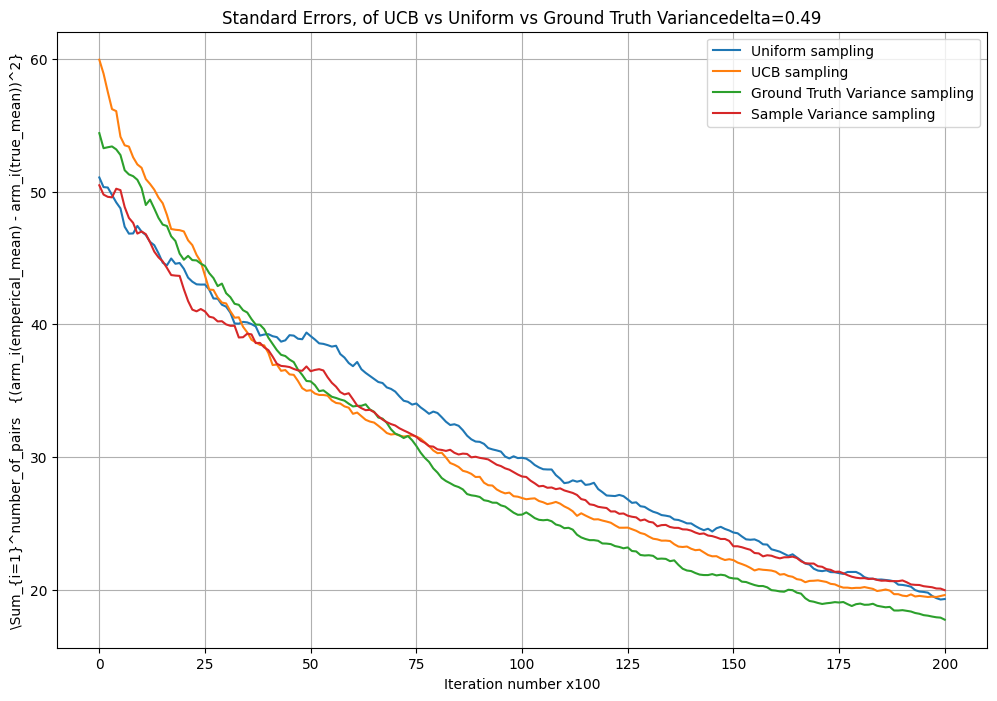

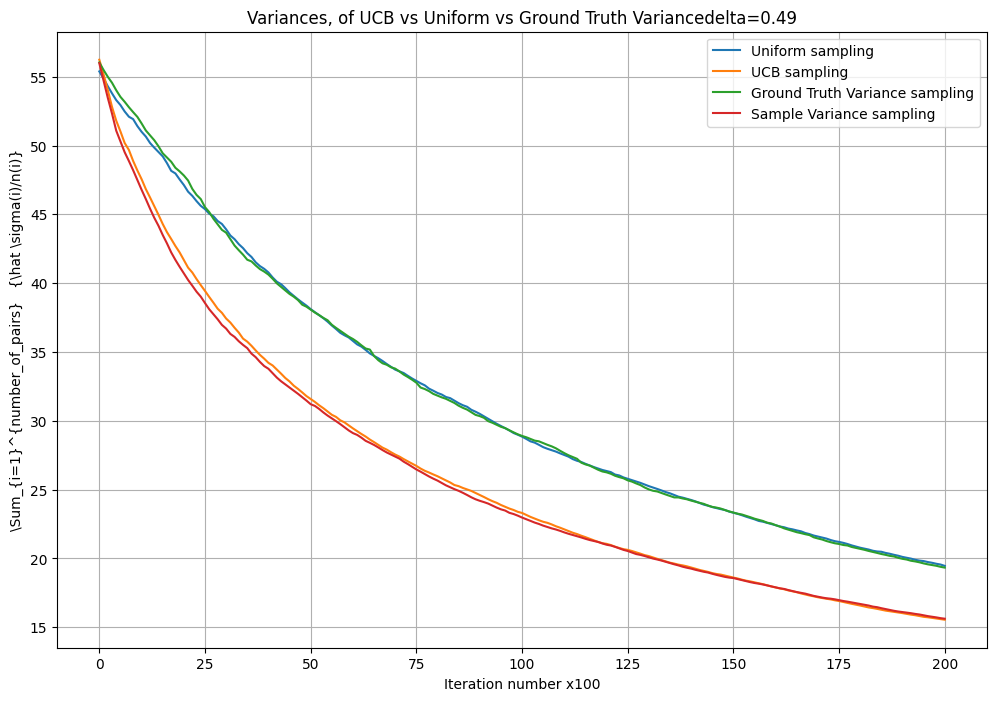

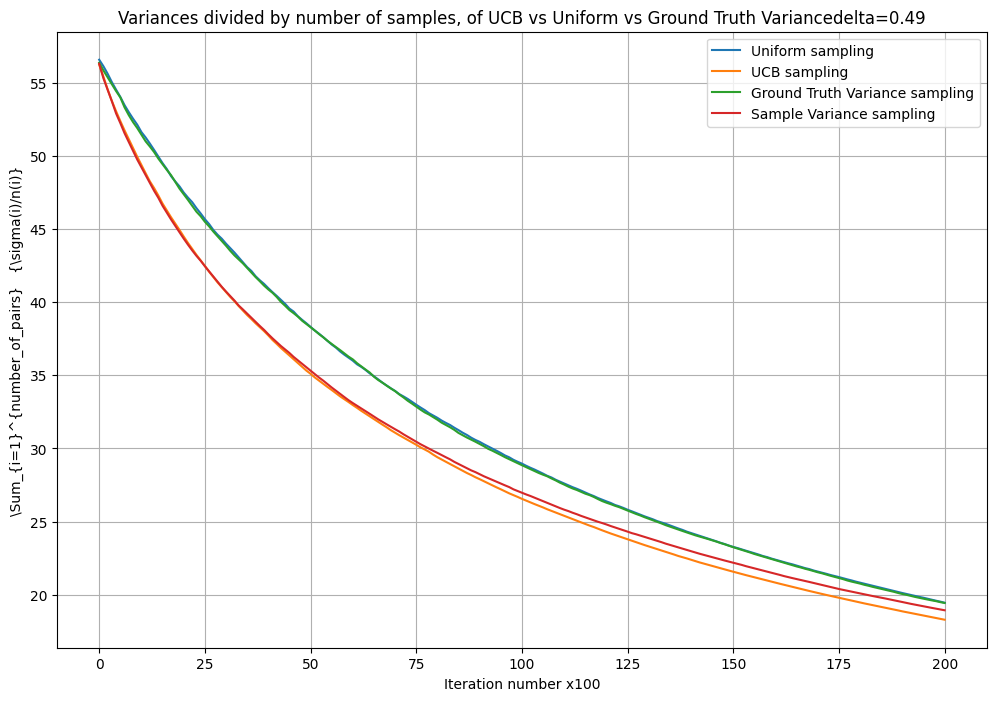

In [18]:
df, metadata = data_reader(files[4])
algorithm = UCB(df, metadata)
number_of_queries = metadata["number_of_pairs"]*number_of_queries_per_pair
print(f"Skipping first {algorithm.n_pairs*algorithm.ucb_burn_in_factor} iterations.")

uniform_errors, uniform_variances, uniform_divided_ground_variance = algorithm.run_algo_uniform(number_of_queries=number_of_queries)
UCB_errors, UCB_variances, UCB_divided_ground_variance = algorithm.run_algo_UCB(number_of_queries=number_of_queries)
ground_truth_variance_errors, ground_truth_variance_variances, ground_truth_variance_divided_ground_variance = algorithm.run_algo_ground_truth_var(number_of_queries=number_of_queries)
sample_variance_errors, sample_variance_variances, sample_variance_divided_ground_variance = algorithm.run_algo_sample_variance(number_of_queries=number_of_queries)

list_of_data_groups = []
metadata_graphs = []

list_of_data_groups.append([uniform_errors, UCB_errors, ground_truth_variance_errors,sample_variance_errors])
metadata_graphs.append({"title": "Standard Errors, of UCB vs Uniform vs Ground Truth Variance", "x_axis": 'Iteration number x100', "y_axis": '\Sum_{i=1}^number_of_pairs   {(arm_i(emperical_mean) - arm_i(true_mean))^2}', "data_labels": ["Uniform sampling", "UCB sampling", "Ground Truth Variance sampling","Sample Variance sampling"]})

list_of_data_groups.append([uniform_variances, UCB_variances, ground_truth_variance_variances, sample_variance_variances])
metadata_graphs.append({"title": "Variances, of UCB vs Uniform vs Ground Truth Variance", "x_axis": 'Iteration number x100', "y_axis": '\Sum_{i=1}^{number_of_pairs}   {\hat \sigma(i)/n(i)}', "data_labels": ["Uniform sampling", "UCB sampling", "Ground Truth Variance sampling", "Sample Variance sampling"]})

list_of_data_groups.append([uniform_divided_ground_variance, UCB_divided_ground_variance, ground_truth_variance_divided_ground_variance, sample_variance_divided_ground_variance])
metadata_graphs.append({"title": "Variances divided by number of samples, of UCB vs Uniform vs Ground Truth Variance", "x_axis": 'Iteration number x100', "y_axis": '\Sum_{i=1}^{number_of_pairs}   {\sigma(i)/n(i)}', "data_labels": ["Uniform sampling", "UCB sampling", "Ground Truth Variance sampling", "Sample Variance sampling"]})

plot_graphs(list_of_group_of_graphs=list_of_data_groups,list_of_groups_of_metadata=metadata_graphs, delta=failure_probability_delta)

# Data Exploration to preprocess

In [ ]:
smaller_temp = temp[temp["predicted_score"] != -1]
print(smaller_temp.shape)

In [ ]:
files = ["data/helpsteer2.jsonl","data/helpsteer2_complexity.jsonl","data/helpsteer2_correctness.jsonl","data/helpsteer2_helpfulness.jsonl","data/helpsteer2_verbosity.jsonl"]
temp = pd.read_json(files[1], lines=True)
# data_metadata = {}
print(temp.shape)
print(sum(temp["predicted_score"] == -1))
arr = temp["prompt"].unique()
print(range(len(arr)))
for index,ele in enumerate(arr):
    print(index,":\t",ele)

# Debugging

In [11]:
algorithm.ground_truth_variances

total_vars = 0
for pair in range(algorithm.n_pairs):
    total_vars += (algorithm.ground_truth_variances[pair]/len(algorithm.responses))
    print(total_vars)

0.00035070468698787286
0.0007295204667696329
0.0009971922683647385
0.0014854623221688611
0.0019836596345254656
0.0024088297025526765
0.002828364281379291
0.0032633009174250155
0.0038666001222626336
0.004269746631603833
0.004668522989082256
0.005003028440307179
0.005199451437231055
0.005500991915762684
0.005876824975961525
0.0060568793898084115
0.00624916607177061
0.006545154673701058
0.007218604948868631
0.007607548464655805
0.008006324822134227
0.00853493839145576
0.008717435933245338
0.008862892171281563
0.00907100701326043
0.009300305104825901
0.009607308273186002
0.009843296473775973
0.010324013178681469
0.010681783637364241
0.010910124072194351
0.011377797874394056
0.012224375443474786
0.01238992839031724
0.012814925658972326
0.012814925658972326
0.013059039610682149
0.013904140353672613
0.014215143432135416
0.014724907876533093
0.015159844512578818
0.015459155745986629
0.01574321561706715
0.016158649806491652
0.017312503678423907
0.01753927242820318
0.018085541411050333
0.0185204

In [6]:
pair = 1000
algorithm.get_ucb_value(pair) # Don't let this be negative.

np.float64(1.5531875334441059)

In [14]:
algorithm.dataframe.iloc[algorithm.metadata["pair_starting_indices"][pair]]

prompt             provide bullet points on the various sections ...
response           In that case, I would recommend including the ...
human_score                                                        1
rationale          The response suggests including the following ...
predicted_score                                                    4
Name: 27804, dtype: object

In [ ]:
print(algorithm.responses[pair])
print(algorithm.get_sample_covariance(algorithm.responses[pair]))
print(metadata["pair_starting_indices"][1016])
print(metadata["pair_number_of_datapoints"][1016])
print((1-(2*math.sqrt(math.log(1/failure_probability_delta,2)/(algorithm.responses[pair].shape[0]+1)))))

In [ ]:
pair_number = 1
print("algorithm.responses[pair_number]:",algorithm.responses[pair_number])
print("algorithm.responses[pair_number].shape[0]", algorithm.responses[pair_number].shape[0])
print("(1-(2*math.sqrt(math.log(1/failure_probability_delta,2)/algorithm.responses[pair_number].shape[0])))", (2*math.sqrt(math.log(1/failure_probability_delta,2)/algorithm.responses[pair_number].shape[0])))
algorithm.get_sample_covariance(algorithm.responses[pair_number])/(1-(2*math.sqrt(math.log(1/failure_probability_delta,2)/algorithm.responses[pair_number].shape[0])))